# EDA — Multiclass Diabetes Dataset (0 / 1 / 2)
**Dataset:** `diabetes_012_health_indicators_BRFSS2015.csv`  
**Source:** CDC Behavioral Risk Factor Surveillance System (BRFSS) 2015  
**Target:** `Diabetes_012` — 0 = No diabetes, 1 = Prediabetes, 2 = Diabetes  

**Goal:** Understand the data structure, class distributions, and key feature relationships across three health states before modeling.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../data/raw/diabetes_multiclass.csv'

CLASS_LABELS = {0: 'No Diabetes', 1: 'Prediabetes', 2: 'Diabetes'}
PALETTE = {0: 'steelblue', 1: 'goldenrod', 2: 'coral'}

## 1. Load & Basic Inspection

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


### Feature Reference
*(Same 21 features as the binary dataset — target is now 3-class)*

| Feature | Type | Description |
|---|---|---|
| `Diabetes_012` | 3-class Target | 0=no diabetes, 1=prediabetes, 2=diabetes |
| `HighBP` | Binary | High blood pressure |
| `HighChol` | Binary | High cholesterol |
| `CholCheck` | Binary | Cholesterol check in past 5 years |
| `BMI` | Integer | Body Mass Index |
| `Smoker` | Binary | Smoked ≥100 cigarettes lifetime |
| `Stroke` | Binary | Ever had a stroke |
| `HeartDiseaseorAttack` | Binary | Coronary heart disease or MI |
| `PhysActivity` | Binary | Physical activity in past 30 days |
| `Fruits` | Binary | Fruit consumption ≥1x/day |
| `Veggies` | Binary | Vegetable consumption ≥1x/day |
| `HvyAlcoholConsump` | Binary | Heavy alcohol use |
| `AnyHealthcare` | Binary | Has healthcare coverage |
| `NoDocbcCost` | Binary | Couldn't see doctor due to cost |
| `GenHlth` | Ordinal (1–5) | General health (1=excellent, 5=poor) |
| `MentHlth` | Integer (0–30) | Poor mental health days (past 30) |
| `PhysHlth` | Integer (0–30) | Poor physical health days (past 30) |
| `DiffWalk` | Binary | Difficulty walking/climbing stairs |
| `Sex` | Binary | 0=female, 1=male |
| `Age` | Ordinal (1–13) | Age category (1=18–24, 13=80+) |
| `Education` | Ordinal (1–6) | Education level |
| `Income` | Ordinal (1–8) | Household income level |

## 2. Data Quality

In [5]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values — dataset is clean.')

Missing values per column:
No missing values — dataset is clean.


In [6]:
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)')

Duplicate rows: 23899 (9.42%)


In [7]:
df_clean = df.drop_duplicates()
print(f'Shape after dedup: {df_clean.shape}')

Shape after dedup: (229781, 22)


> **Why this matters for modeling:** Duplicate rows create data leakage if the same record lands in both train and test sets — the model hasn't generalized, it's memorized. This is especially dangerous for the already-tiny prediabetes class (class 1): if duplicates of class 1 records inflate the training set, the model will look better than it actually is, and real-world performance on unseen prediabetics will disappoint. Always drop duplicates before splitting.

In [8]:
print('Diabetes_012 unique values:', sorted(df['Diabetes_012'].unique()))

Diabetes_012 unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


## 3. Target Variable — Class Imbalance (3-Class)

Class Distribution:
         Class   Count  Percent
0  No Diabetes  190055    82.71
1  Prediabetes    4629     2.01
2     Diabetes   35097    15.27


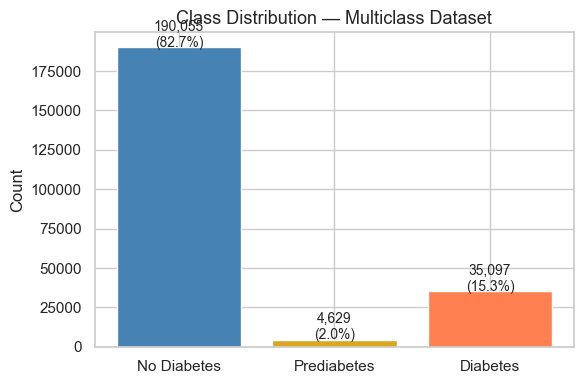

In [9]:
counts = df_clean['Diabetes_012'].value_counts().sort_index()
pcts   = df_clean['Diabetes_012'].value_counts(normalize=True).sort_index() * 100

print('Class Distribution:')
print(pd.DataFrame({'Class': [CLASS_LABELS[i] for i in counts.index],
                    'Count': counts.values,
                    'Percent': pcts.values.round(2)}))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([CLASS_LABELS[i] for i in counts.index],
              counts.values,
              color=[PALETTE[i] for i in counts.index],
              edgecolor='white')
for bar, (c, p) in zip(bars, zip(counts.values, pcts.values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{c:,}\n({p:.1f}%)', ha='center', fontsize=10)
ax.set_title('Class Distribution — Multiclass Dataset', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

> **This is the defining challenge of this dataset.** Class 1 (Prediabetes) represents only ~2% of records — roughly 7x fewer than the already-minority diabetes class, and ~42x fewer than the no-diabetes class. This is not a mild imbalance; it is an extreme one.
>
> A model that ignores class 1 entirely and only predicts 0 or 2 would still achieve ~98% recall on the majority classes. This means **overall accuracy is completely meaningless here**. The model that matters is one that can actually detect prediabetes.
>
> **Why does catching prediabetes matter?** Prediabetes is the intervention window — it is a reversible condition where lifestyle changes can prevent progression to full diabetes. A model that misses class 1 is clinically useless for early intervention.
>
> **What to do:**
> - Use **macro F1** as the primary metric — it weights all three classes equally regardless of size
> - Use `class_weight='balanced'` or manually upweight class 1
> - Consider targeted **SMOTE** for class 1 only
> - For XGBoost: use `scale_pos_weight` or the `sample_weight` parameter
> - Evaluate with a **per-class confusion matrix** — inspect class 1 recall specifically

## 4. Binary vs. Multiclass: What We Gain

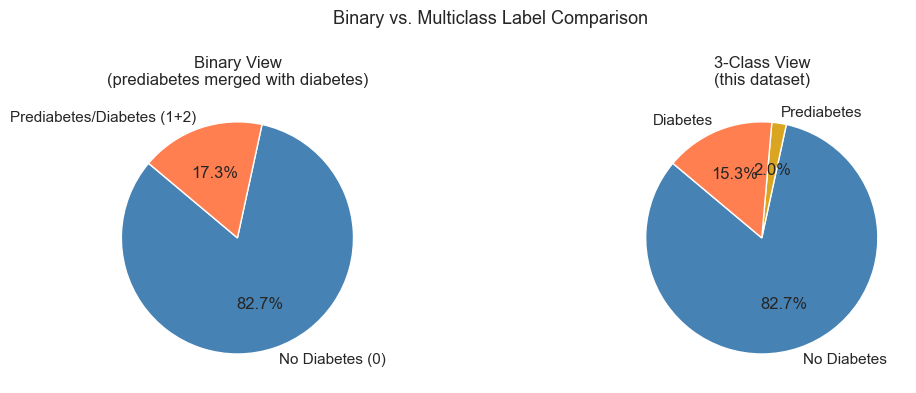

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

binary_counts_collapsed = pd.Series({
    'No Diabetes (0)': counts[0],
    'Prediabetes/Diabetes (1+2)': counts[1] + counts[2]
})
axes[0].pie(binary_counts_collapsed, labels=binary_counts_collapsed.index,
            autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=140)
axes[0].set_title('Binary View\n(prediabetes merged with diabetes)')

axes[1].pie(counts, labels=[CLASS_LABELS[i] for i in counts.index],
            autopct='%1.1f%%', colors=[PALETTE[i] for i in counts.index], startangle=140)
axes[1].set_title('3-Class View\n(this dataset)')

plt.suptitle('Binary vs. Multiclass Label Comparison', fontsize=13)
plt.tight_layout()
plt.show()

> **Why split the target at all?** The binary dataset collapses prediabetes into the positive class, treating someone with borderline blood sugar the same as someone with full Type 2 diabetes. The multiclass version lets us ask whether features can actually distinguish these two conditions — and whether a model can identify people who are *at risk* before disease onset. This is the more clinically valuable (and much harder) prediction task.

## 5. Continuous Features — Distributions Across 3 Classes

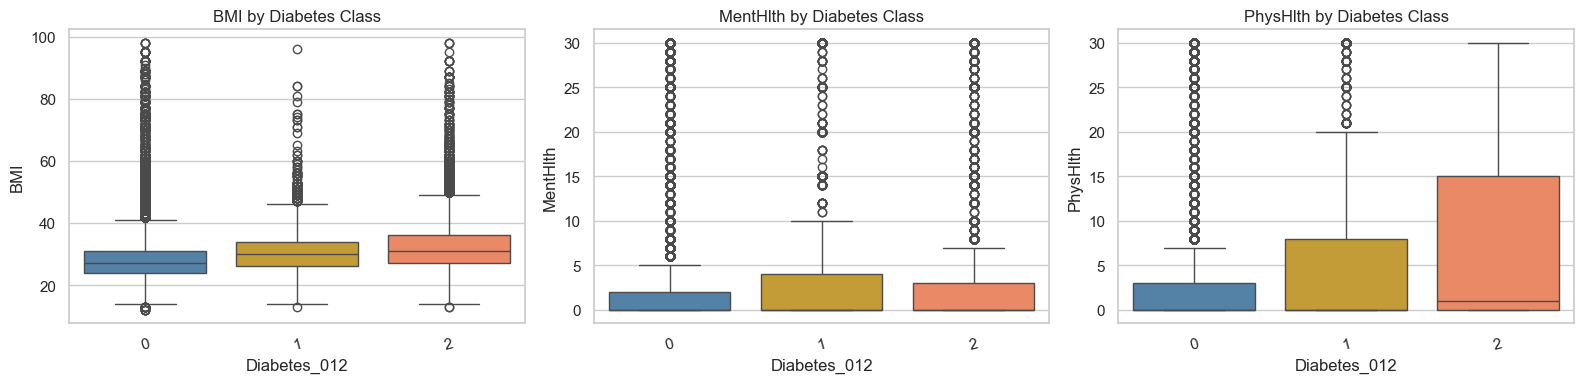

In [11]:
continuous = ['BMI', 'MentHlth', 'PhysHlth']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, continuous):

    sns.boxplot(
        data=df_clean,
        x='Diabetes_012',
        y=col,
        hue='Diabetes_012',
        palette=PALETTE,
        dodge=False,
        ax=ax
    )

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(CLASS_LABELS, rotation=15)
    ax.set_title(f'{col} by Diabetes Class')

    ax.legend_.remove()

plt.tight_layout()
plt.show()


In [12]:
print('Mean values per class:')
df_clean.groupby('Diabetes_012')[continuous].mean().round(2)

Mean values per class:


,BMI,MentHlth,PhysHlth
Diabetes_012,,,
0.0,28.03,3.30,4.02
1.0,30.73,4.53,6.35
2.0,31.96,4.49,8.01


> **What we're seeing and why it matters:**
>
> **BMI:** The no-diabetes group has the lowest average BMI (28.03), while prediabetes (30.73) and diabetes (31.96) show a clear increasing trend. This is one of the strongest monotonic relationships in the dataset, indicating BMI is a key risk factor. However, there is still noticeable overlap between classes, especially between prediabetes and diabetes.
>
> **PhysHlth:** Physical health days also increase steadily from class 0 → 1 → 2 (4.02 → 6.35 → 8.01). This suggests worsening physical health is strongly associated with diabetes progression, though the separation is not sharp due to overlapping distributions.
>
> **MentHlth:** Mental health days show only a weak trend (3.30 → 4.53 → 4.49), with prediabetes and diabetes nearly indistinguishable. This confirms that MentHlth is a noisy and weak predictor in this dataset, likely due to high variance and zero inflation.
>
> **Core insight:** The strongest signal comes from BMI and physical health, both of which show a clear increasing trend across classes. However, even these features exhibit substantial overlap, meaning the multiclass problem is not cleanly separable and will likely require non-linear models (e.g., tree-based ensembles) rather than linear classifiers.

## 6. Ordinal Features — Class Proportions by Level

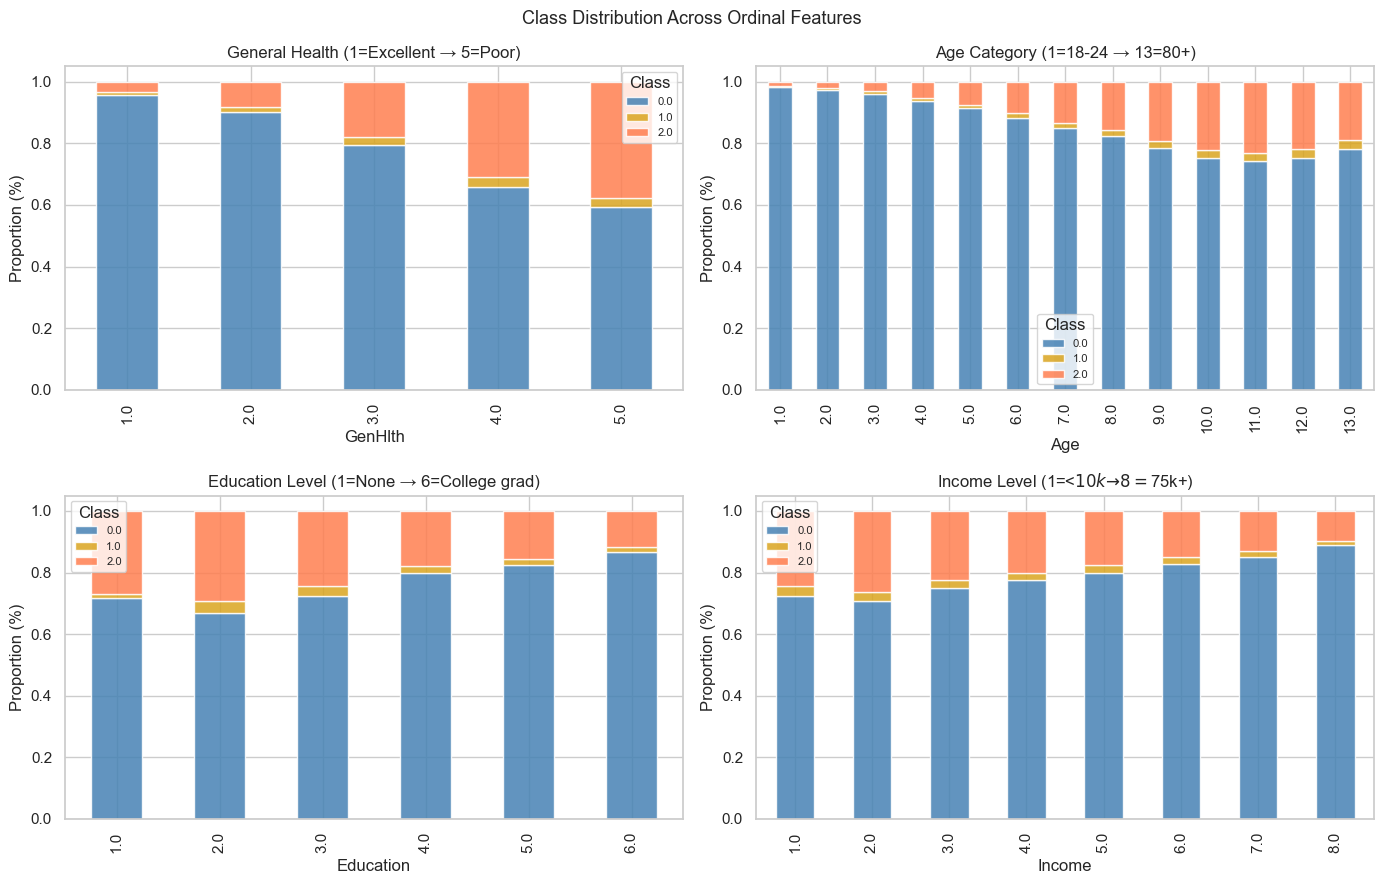

In [19]:
ordinal = {
    'GenHlth': 'General Health (1=Excellent → 5=Poor)',
    'Age': 'Age Category (1=18-24 → 13=80+)',
    'Education': 'Education Level (1=None → 6=College grad)',
    'Income': 'Income Level (1=<$10k → 8=$75k+)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, ordinal.items()):

    props = (
        df_clean.groupby(col)['Diabetes_012']
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )

    props = props[[0, 1, 2]]

    props.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=[PALETTE[0], PALETTE[1], PALETTE[2]],
        alpha=0.85,
        edgecolor='white'
    )

    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('Proportion (%)')
    ax.legend(title='Class', fontsize=8)

plt.suptitle('Class Distribution Across Ordinal Features', fontsize=13)
plt.tight_layout()
plt.show()

> **What we're seeing and why it matters:**
>
> **GenHlth** remains the strongest ordinal predictor in the 3-class setting too. As self-reported health worsens (1→5), the proportion of diabetes (class 2) grows dramatically while no-diabetes (class 0) shrinks. Prediabetes (class 1, goldenrod) stays small and relatively flat across levels — it doesn't cluster strongly at any particular health rating. This tells us GenHlth is more useful for separating class 2 from class 0 than for detecting class 1.
>
> **Age** shows a clear trend: older age groups have far higher proportions of diabetes. Prediabetes stays small across all age groups, but its relative share is slightly higher in middle-age categories (ages 7–9, roughly 45–64) — this is clinically consistent with when prediabetes is most commonly diagnosed and managed.
>
> **Income and Education** both show the inverse socioeconomic gradient seen in the binary dataset. Higher income and education correlate with lower diabetes prevalence. Prediabetes proportion changes little across income levels — possibly reflecting that prediabetes detection itself is income-dependent (you need healthcare access to get screened).
>
> **Modeling implication:** These ordinal features will help discriminate class 2 from class 0, but contribute little to identifying class 1. This is why prediabetes is the hard class.

## 7. Binary Features — Risk Factor Profiles by Class

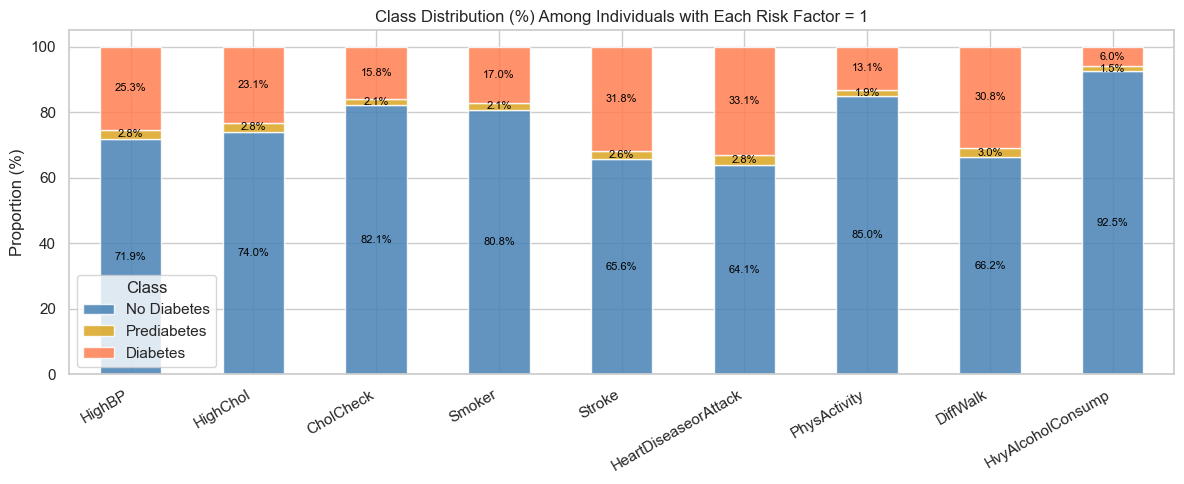

In [14]:
binary_features = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke',
    'HeartDiseaseorAttack','PhysActivity','DiffWalk','HvyAlcoholConsump'
]

summary = {}

for col in binary_features:

    grp = (
        df_clean[df_clean[col] == 1]['Diabetes_012']
        .value_counts(normalize=True)
        .sort_index() * 100
    )

    summary[col] = {
        CLASS_LABELS[k]: grp.get(k, 0) for k in [0, 1, 2]
    }

summary_df = pd.DataFrame(summary).T

plot_df = summary_df[[CLASS_LABELS[0], CLASS_LABELS[1], CLASS_LABELS[2]]]

fig, ax = plt.subplots(figsize=(12, 5))

plot_df.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[PALETTE[0], PALETTE[1], PALETTE[2]],
    alpha=0.85,
    edgecolor='white'
)

# --- ADD ALL LABELS (including small ones) ---
for i in range(len(plot_df)):
    cumulative = 0
    for j, col in enumerate(plot_df.columns):
        value = plot_df.iloc[i, j]

        if value > 0:
            ax.text(
                i,
                cumulative + value / 2,
                f'{value:.1f}%',
                ha='center',
                va='center',
                fontsize=8,
                color='black'
            )
            cumulative += value

ax.set_title('Class Distribution (%) Among Individuals with Each Risk Factor = 1', fontsize=12)
ax.set_ylabel('Proportion (%)')
ax.set_xlabel('')
ax.legend(title='Class')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

> **What we're seeing and why it matters:**
>
> For most risk factors, people with the feature (feature=1) show a higher proportion of diabetes (class 2, coral) compared to the dataset baseline (~14%). **HighBP, Stroke, HeartDiseaseorAttack, and DiffWalk** are the strongest signals — having any of these dramatically shifts the class mix toward diabetes.
>
> Prediabetes (goldenrod) remains a small sliver across all risk factors. This is partly a data artifact of extreme class imbalance, but it also reflects a real clinical phenomenon: prediabetes often goes undetected and may not yet produce the comorbidities that are more visible with full diabetes.
>
> **PhysActivity** (having been active) shows a slightly lower proportion of class 2 among active respondents — reinforcing its protective role even within the 3-class framing.
>
> **HvyAlcoholConsump** again shows a lower class 2 proportion among heavy drinkers — the same likely survivor/selection bias artifact as in the binary dataset. Do not interpret as protective.

## 8. Correlation Analysis

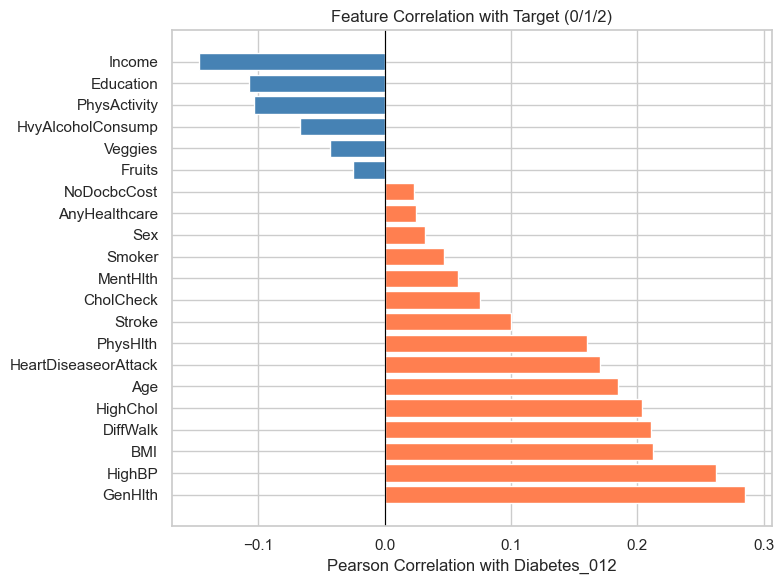

GenHlth                 0.284881
HighBP                  0.261976
BMI                     0.212027
DiffWalk                0.210638
HighChol                0.203327
Age                     0.184642
HeartDiseaseorAttack    0.170816
PhysHlth                0.160485
Stroke                  0.100276
CholCheck               0.075701
MentHlth                0.057698
Smoker                  0.046774
Sex                     0.032243
AnyHealthcare           0.024911
NoDocbcCost             0.023568
Fruits                 -0.025462
Veggies                -0.043446
HvyAlcoholConsump      -0.067164
PhysActivity           -0.103408
Education              -0.107742
Income                 -0.147102
Name: Diabetes_012, dtype: float64


In [15]:
corr_target = df_clean.corr()['Diabetes_012'].drop('Diabetes_012').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['coral' if c > 0 else 'steelblue' for c in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Diabetes_012')
ax.set_title('Feature Correlation with Target (0/1/2)')
plt.tight_layout()
plt.show()

print(corr_target)

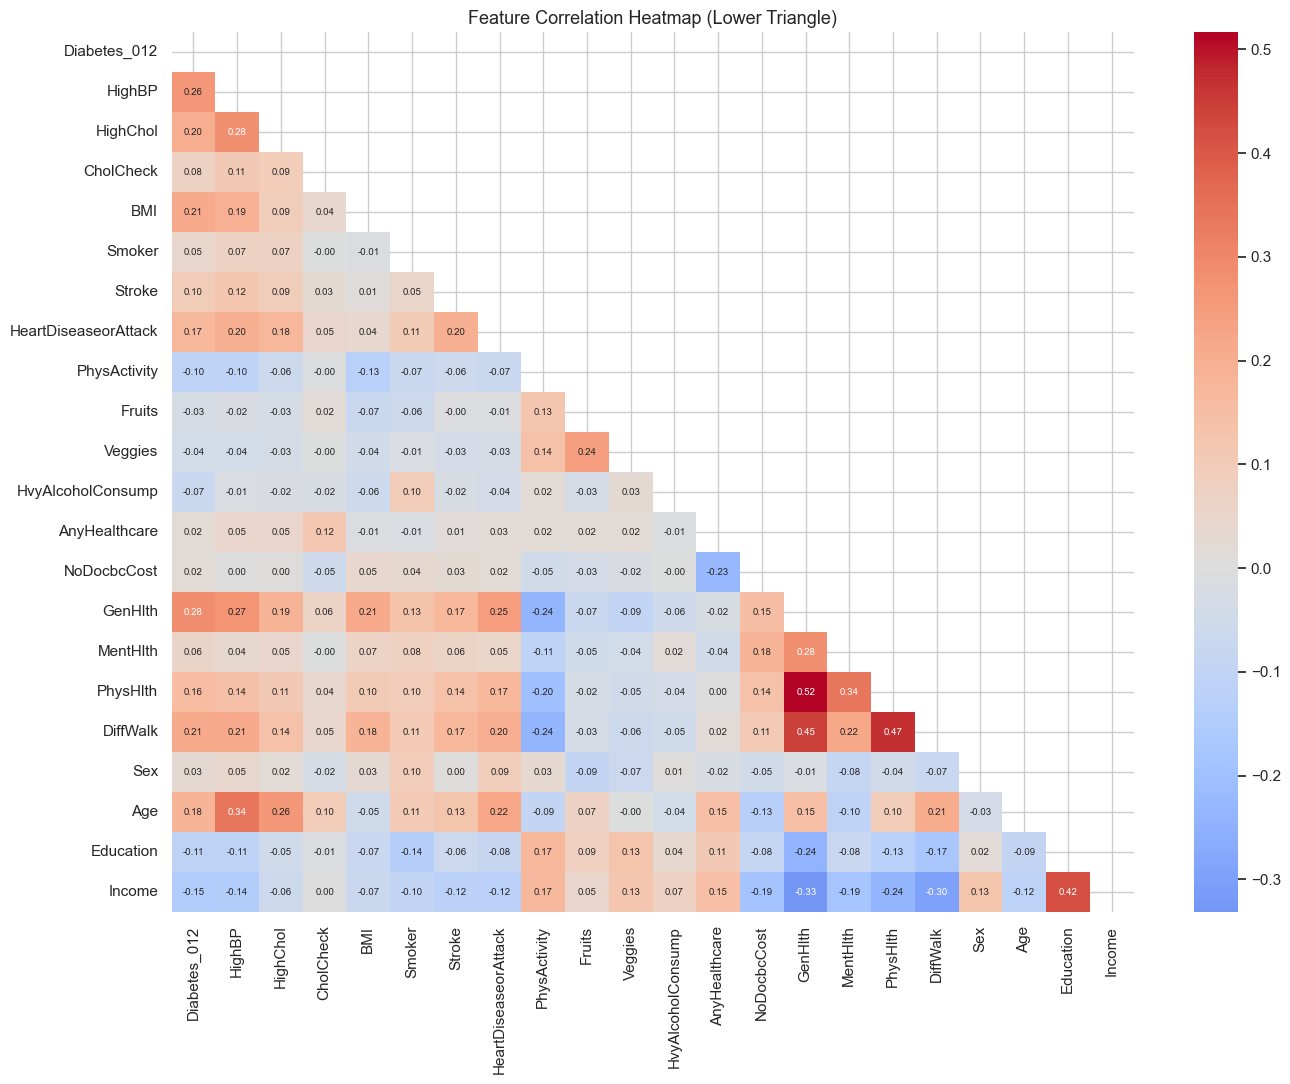

In [16]:
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(df_clean.corr(), dtype=bool))
sns.heatmap(df_clean.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.show()

> **What we're seeing and why it matters:**
>
> The feature ranking here is nearly identical to the binary dataset — GenHlth, HighBP, BMI, DiffWalk, and HighChol are top positive correlates; Income, Education, and PhysActivity are top negative ones. This is expected because the 3-class target is still ordinally encoded (0 < 1 < 2) and Pearson correlation treats it as such.
>
> **Important caveat for the multiclass setting:** Pearson correlation treats class 1 (prediabetes) as halfway between classes 0 and 2. In reality, class 1 might not behave linearly between them — it could be closer to 0 on some features and closer to 2 on others. A feature with low correlation here might still be the key to distinguishing class 1. This is why tree-based models that can capture nonlinear, non-ordinal class relationships are especially important for this dataset.
>
> **Multicollinearity:** Same structure as the binary dataset — PhysHlth/GenHlth (0.52) and DiffWalk/PhysHlth (0.47) are the highest inter-feature correlations. Regularize logistic regression; tree models handle this automatically.

## 9. The Prediabetes Problem — Class 1 Separability

In [17]:
mean_by_class = df_clean.groupby('Diabetes_012').mean()
diff_1_vs_0 = (mean_by_class.loc[1] - mean_by_class.loc[0]).abs().sort_values(ascending=False)
diff_1_vs_2 = (mean_by_class.loc[1] - mean_by_class.loc[2]).abs().sort_values(ascending=False)
diff_0_vs_2 = (mean_by_class.loc[0] - mean_by_class.loc[2]).abs().sort_values(ascending=False)


print('Top features separating Class 1 (Prediabetes) from Class 0 (No Diabetes):')
print(diff_1_vs_0.drop('Diabetes_012', errors='ignore').round(4).head(10))
print()
print('Top features separating Class 1 (Prediabetes) from Class 2 (Diabetes):')
print(diff_1_vs_2.drop('Diabetes_012', errors='ignore').round(4).head(10))
print('Top features separating Class 0 (No Diabetes) vs Class 2 (Diabetes):')
print(diff_0_vs_2.drop('Diabetes_012', errors='ignore').round(4).head(10))

Top features separating Class 1 (Prediabetes) from Class 0 (No Diabetes):
BMI          2.6955
PhysHlth     2.3322
Age          1.2579
MentHlth     1.2340
Income       0.6810
GenHlth      0.5123
Education    0.2459
HighBP       0.2339
HighChol     0.2255
DiffWalk     0.1291
dtype: float64

Top features separating Class 1 (Prediabetes) from Class 2 (Diabetes):
PhysHlth                1.6574
BMI                     1.2382
GenHlth                 0.3199
Age                     0.2939
Income                  0.1550
HighBP                  0.1233
DiffWalk                0.0961
HeartDiseaseorAttack    0.0804
PhysActivity            0.0498
HighChol                0.0486
dtype: float64
Top features separating Class 0 (No Diabetes) vs Class 2 (Diabetes):
PhysHlth     3.9897
BMI          3.9337
Age          1.5517
MentHlth     1.1955
Income       0.8360
GenHlth      0.8322
HighBP       0.3572
Education    0.2900
HighChol     0.2741
DiffWalk     0.2251
dtype: float64


> **This is the core insight for the multiclass structure.** Class 0 (No Diabetes) and Class 2 (Diabetes) are strongly separable across nearly all major features, especially BMI and physical health indicators. In contrast, Class 1 (Prediabetes) does not form a distinct cluster — it consistently shows intermediate values and overlaps heavily with both groups.
>
> The pairwise mean differences confirm this structure: Class 0 vs Class 2 shows large separations across BMI (~3.9), PhysHlth (~4.0), and Age (~1.55), indicating strong underlying signal between healthy and diabetic populations. However, Class 1 vs either class shows substantially smaller differences, reinforcing that prediabetes lies in a transitional risk zone rather than a clearly separable class.
>
> **Modeling implications:**
> - Class 0 and Class 2 will be well-learned by most models
> - Class 1 will remain the hardest class and likely the lowest recall category
> - Models may bias predictions toward Class 0 vs Class 2 and under-represent Class 1 structure
> - Tree-based models (XGBoost / LightGBM) will be more effective at capturing nonlinear boundaries in this transition region
> - SHAP analysis is critical to verify whether Class 1 predictions are driven by meaningful physiological patterns or noise

## 10. Preprocessing & Modeling Checklist

| Issue | Finding | Action |
|---|---|---|
| **Severe Class Imbalance** | Class 1 ~2%, Class 0 ~84%, Class 2 ~14% | Use **macro F1**, `class_weight='balanced'`, oversample Class 1 |
| **Duplicate rows** | Significant number | Drop **before** split — especially important for Class 1 |
| **BMI outliers** | Values >60 | Cap at 99th percentile for LR/SVM/KNN; trees are robust |
| **MentHlth weak signal** | Zero-inflated, poor class separation | Consider binarizing or dropping |
| **Multicollinearity** | PhysHlth–GenHlth (0.54), DiffWalk–PhysHlth (0.43) | Regularize LR; not an issue for tree models |
| **Ordinal encoding** | GenHlth, Age, Education, Income already numeric | Preserve as-is; scale for LR/SVM |
| **OvR vs Softmax** | 3-class problem | LR/SVM: One-vs-Rest; XGBoost: `objective='multi:softmax'` |
| **No missing values** | Dataset is clean | No imputation needed |

---
> **The defining challenge:** Almost every feature separates class 0 from class 2 reasonably well. The hard problem — and the clinically important one — is detecting class 1 (prediabetes) before it becomes class 2 (diabetes).

In [18]:
print('Feature means by class:')
df_clean.groupby('Diabetes_012').mean().round(3)

Feature means by class:


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_012,,,,,,,,,,,,,,,,,,,,,
0.0,0.395,0.395,0.953,28.031,0.455,0.036,0.080,0.754,0.619,0.803,...,0.944,0.089,2.464,3.298,4.019,0.149,0.432,7.824,5.030,6.032
1.0,0.629,0.621,0.987,30.726,0.493,0.057,0.143,0.678,0.603,0.769,...,0.945,0.129,2.976,4.532,6.351,0.278,0.437,9.082,4.784,5.351
2.0,0.752,0.669,0.993,31.964,0.519,0.093,0.224,0.629,0.584,0.755,...,0.959,0.107,3.296,4.493,8.008,0.374,0.477,9.376,4.740,5.196
